In [1]:
import numpy as np
from astropy.io import fits
import matplotlib.pyplot as plt
import astropy.constants as const
import astropy.units as u
from matplotlib.ticker import StrMethodFormatter
%config InlineBackend.figure_format = 'retina'
import pyneb as pn
import matplotlib
from matplotlib.colors import Normalize
import math
plt.style.use('mplstyle.txt')

In [2]:
c = const.c.cgs.value   
k_B = const.k_B.cgs.value
m_p = const.m_p.cgs.value 
m_H = m_p  # mass of hydrogen atom in grams
m_O = 16 * m_p  # mass of oxygen atom in grams

O3 = pn.Atom(atom = 'O3')  # O3
H1 = pn.RecAtom('H', 1)  # H-beta

In [3]:
def weights(x, y, R, dR=None):
    if dR is None: dR=0. * R
    rho2 = x**2 + y**2
    Rin, Rout = R - 0.5 * dR, R + 0.5 * dR
    outs = np.where(rho2 < Rout**2, np.sqrt(Rout**2 - rho2), 0.0)
    ins = np.where(rho2 < Rin**2, np.sqrt(Rin**2 - rho2), 0.0)
    
    # line-of-sight path length
    w = 2.0 * (outs - ins)
    
    return w  
def los_vel(x, y, R, k, ncomp):
    rho2 = x**2 + y**2
    inside = (rho2 <= R**2)

    v_near = np.where(inside, (k / R) * np.sqrt(R**2 - rho2) / R, 0.0)
    v_far  = -v_near

    if ncomp == 1:
        v = np.array([0.0])
    elif ncomp == 2:
        v = np.array([float(v_far), float(v_near)])
    else:
        v = np.linspace(float(v_far), float(v_near), ncomp)
    return v

def getflux(ion, wl, T, ne, ni = None):
    if ni is None: ni = ne * 1e-4  # rough estimate from ISM densities
    eps = ion.getEmissivity(tem=T, den=ne, wave=wl)
    j = eps * ne * ni # emissivity per unit volume
    return j

# gaussian profile
def getgauss(wl, wl0, sigma, flux):
    amp = flux / (np.sqrt(2 * np.pi) * sigma)
    profile = amp * np.exp(-0.5 * ((wl - wl0) / sigma)**2)
    return profile, amp

def comp_array(x, ncomp, name="array"):
    x = np.asarray(x)
    x = np.atleast_1d(x).astype(float)
    if x.size == 1:
        return np.full(ncomp, float(x[0]))
    if x.size != ncomp:
        raise ValueError(f"{name} must be scalar or length {ncomp}, got length {x.size}")
    return x

In [4]:
def getspectrum(wl, T, ne, lines, vel, x=None, y=None, R=None, dR=None, static=False, sigmas=None, amps=None, k=None):
    wl = np.asarray(wl)
    spectrum = np.zeros_like(wl, dtype=float)
    info = []

    # number of components from the size of the sigma array
    if sigmas is not None:
        ncomp = np.atleast_1d(np.asarray(sigmas)).size
    else:
        ncomp = 1

    if sigmas is None:
        sigmas = 0.0
    
    if amps is None:
        amps = 1.0

    sig_arr = comp_array(sigmas, ncomp, name= 'sigmas')  # Angstrom
    amp_arr = comp_array(amps,   ncomp, name= 'amps')

    s = np.sum(amp_arr)
    if s > 0:
        amp_arr = amp_arr / s

    # line of sight velocities for a spherical shell
    if (not static):
        vel_arr = los_vel(x, y, R, k, ncomp)  # km/s
    else:
        vel_arr = np.zeros(ncomp, dtype=float)

    for line in lines:
        ion  = line['ion']
        lam0 = line['wl']
        mass = line['mass']
        ni   = line.get('ni', 1e-4 * ne)

        # emissivity
        j = getflux(ion, lam0, T, ne, ni=ni)

        # geometry
        if (x is not None) and (y is not None) and (R is not None) and (dR is not None):
            weight = weights(x, y, R, dR)
            F = j * weight
        else:
            F = j

        for kk in range(ncomp):
            sigma = float(sig_arr[kk])
            if sigma <= 0:
                continue

            if static:
                lam_c = lam0
            else:
                lam_c = lam0 * (1 + (float(vel_arr[kk]) * 1e5) / c)

            prof, amp = getgauss(wl, lam_c, sigma, F * amp_arr[kk])
            spectrum += prof

            info.append({
                'wl': lam0,
                'flux': F * amp_arr[kk],
                'sigma': sigma,
            })

    return spectrum, info

In [5]:
hdul = fits.open('data/SMC_SNR/b0886.norm.dc.fits'); bflux = hdul[0].data
hdul = fits.open('data/SMC_SNR/r0886.norm.dc.fits'); rflux = hdul[0].data
if 'CD1_1' in list(hdul[0].header.keys()):
    wave = hdul[0].header['CRVAL1'] + hdul[0].header['CD1_1'] * (np.arange(hdul[0].header['NAXIS1']) - hdul[0].header['CRPIX1'] + 1)
else: wave = hdul[0].header['CRVAL1'] + hdul[0].header['CDELT1'] * (np.arange(hdul[0].header['NAXIS1']) - hdul[0].header['CRPIX1'] + 1)

# noise is the sqrt of the variance
hdul = fits.open('data/SMC_SNR/b0886_var.norm.dc.fits'); bnoise = np.sqrt(hdul[0].data)
hdul = fits.open('data/SMC_SNR/r0886_var.norm.dc.fits'); rnoise = np.sqrt(hdul[0].data)

noise = np.concatenate((bnoise, rnoise))
flux = np.concatenate((bflux, rflux))

In [6]:
hex = np.loadtxt('fibers.csv', delimiter=',', skiprows=7, usecols=(5,6), max_rows=552)
sorted_data = []  # sort the data in a snake-like pattern (native to IFUM)

for i, y in enumerate(np.unique(hex[:, 1])):  # get all vertical values
    row_data = hex[ hex[:, 1] == y ]  # just take information for each individual row
    sorted_indices = np.argsort(row_data[:, 0])  # sort by x coord
    if i % 2 == 0:  # even index rows go right-to-left, odd go left-to-right
        sorted_indices = sorted_indices[::-1]
    sorted_data.extend(row_data[sorted_indices])

hex = np.array(sorted_data)

In [7]:
x_arr, y_arr = hex[:,0], hex[:,1]

center = 282 # spaxel corresponding to the center of the SNR 
x0, y0 = x_arr[center], y_arr[center]
x_sph = x_arr - x0; y_sph = y_arr - y0

Rlist = [8, 12, 16 ]  # shell radii in arcsec
klist = [4500, -3000, 2000]  # velocity scales in km/s


near, far, vels = [], [], []
for R, k in zip(Rlist, klist):
    rho2 = x_sph**2 + y_sph**2
    v_near = np.where(rho2 <= R**2, (k / R) * np.sqrt(R**2 - rho2) / R, 0.0)
    v_far = -v_near
    v = np.concatenate((v_far, v_near))
    near.append(v_near) ; far.append(v_far) ; vels.append(v)

idx = 200  # spaxel index
T = 2600 # temperature in K
ne = 30 # electron density in cm^-3
velstat = 22 # km/s, internal velocity dispersion of ISM in SMC from Stanimirovic (2001)

lines = [
    {'ion': O3,  'wl': 4959, 'mass': m_O},
    {'ion': O3,  'wl': 5007, 'mass': m_O},
    {'ion': H1,  'wl': 4861, 'mass': m_H}]

/var/folders/qt/651sdhvj0s1fclkvz53_53s00000gn/T/ipykernel_25666/3006971064.py:14: RuntimeWarning: invalid value encountered in sqrt
  v_near = np.where(rho2 <= R**2, (k / R) * np.sqrt(R**2 - rho2) / R, 0.0)


In [8]:
shells = []

for i in range(len(near)):
    R  = Rlist[i]
    k  = klist[i]
    x, y = x_sph[idx], y_sph[idx]

    # REPLACE WITH ACTUAL SIGMA ARRAY PER SPAXEL
    sigmas = 1.0

    s, _ = getspectrum(
        wave, T, ne, lines[0:2],  # only O3 lines for shells
        vel=None,
        x=x,
        y=y,
        R=R,
        dR = 3,
        sigmas=sigmas,
        k=k
    )

    shells.append(s)
    
spec_tot = np.sum(shells, axis=0)

# REPLACE WITH ACTUAL STATIC LINE SIGMAS
sigmas_static = 1.0
static, _ = getspectrum(
        wave, T, ne, lines,
        vel = velstat,
        x = x_sph[idx],
        y = y_sph[idx],
        R = Rlist[0],
        dR = 3,
        static=True,
        sigmas=sigmas_static
    )

/var/folders/qt/651sdhvj0s1fclkvz53_53s00000gn/T/ipykernel_25666/1868967943.py:16: RuntimeWarning: invalid value encountered in sqrt
  v_near = np.where(inside, (k / R) * np.sqrt(R**2 - rho2) / R, 0.0)
/var/folders/qt/651sdhvj0s1fclkvz53_53s00000gn/T/ipykernel_25666/1868967943.py:5: RuntimeWarning: invalid value encountered in sqrt
  outs = np.where(rho2 < Rout**2, np.sqrt(Rout**2 - rho2), 0.0)
/var/folders/qt/651sdhvj0s1fclkvz53_53s00000gn/T/ipykernel_25666/1868967943.py:6: RuntimeWarning: invalid value encountered in sqrt
  ins = np.where(rho2 < Rin**2, np.sqrt(Rin**2 - rho2), 0.0)


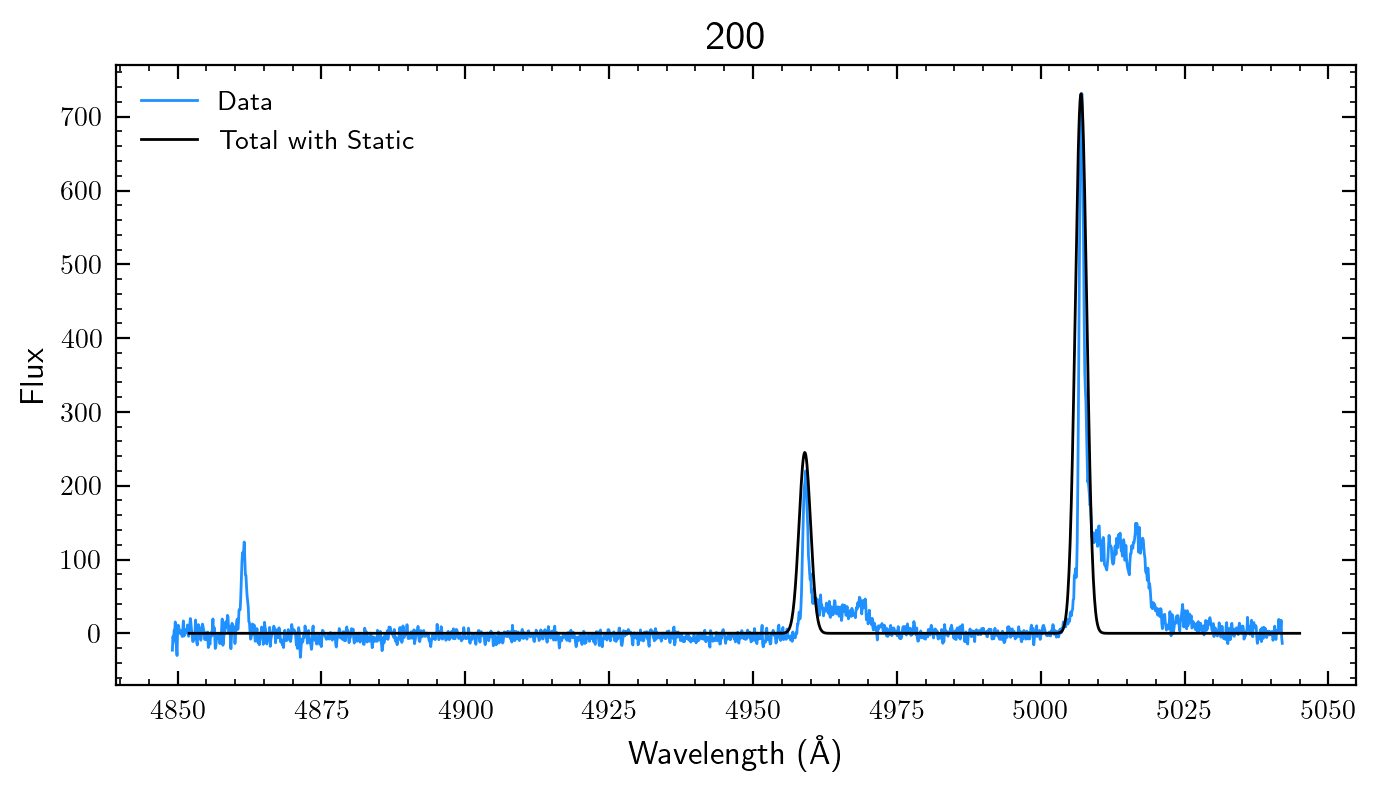

In [9]:
data = flux[idx] - np.median(flux[idx])
# scale = np.max(data) / np.max(spec_tot)
scale = np.max(data) / np.max( (static + spec_tot) )
# scale = 1

z = (5010 - 5007) / 5007 # our data has offset, correcting for that

plt.figure(figsize=(8, 5))

plt.plot(wave / (1 + z), data, lw = 1,label='Data', color='dodgerblue')

# plt.plot(wave, static * scale, lw=1, color='orangered', label='Static', alpha = 0.7)

# for i, s in enumerate(shells):
#     plt.plot(wave, s * scale, lw=1, label=f'Shell {i+1}')

# plt.plot(wave, spec_tot, lw = 1, color='k', label='Total')

plt.plot(wave, (spec_tot + static) * scale, lw = 1, color='k', label='Total with Static')

plt.gca().set_box_aspect(0.5)
plt.xlabel('Wavelength (Å)')
plt.ylabel('Flux')
plt.title(f'{idx}')
plt.legend(loc = 'upper left')

# plt.ylim(None, 15)

In [10]:
mockflux = [] ; mocktotal = []

for i in range(len(flux)):
    shells = []
    for j in range(len(near)):
        R  = Rlist[j]
        k  = klist[j]
        x, y = x_sph[i], y_sph[i]

        # REPLACE WITH ACTUAL SIGMA ARRAY PER SPAXEL
        sigmas = 1.0

        s, _ = getspectrum(
            wave, T, ne, lines[0:2],  # only O3 lines for shells
            vel=None,
            x=x,
            y=y,
            R=R,
            dR = None,
            sigmas=sigmas,
            k=k
        )
    
        shells.append(s)
    
    spec_tot = np.sum(shells, axis=0)

    # REPLACE WITH ACTUAL STATIC LINE SIGMAS
    sigmas_static = 1.0

    static, _ = getspectrum(
           wave, T, ne, lines,
           vel = velstat,
           x = x_sph[i],
           y = y_sph[i],
           R = Rlist[0],
           dR = None,
           static=True,
           sigmas=sigmas_static
       )
    
    mockflux.append((spec_tot + static))
    mocktotal.append(np.sum(mockflux[i]))

mocktotal = np.array(mocktotal) / np.array(mocktotal).max()

/var/folders/qt/651sdhvj0s1fclkvz53_53s00000gn/T/ipykernel_25666/1868967943.py:16: RuntimeWarning: invalid value encountered in sqrt
  v_near = np.where(inside, (k / R) * np.sqrt(R**2 - rho2) / R, 0.0)


In [11]:
def maps(cvals, ax, fig, vlim=None, c=0):
    if vlim == None: vmin=np.percentile(cvals, 10); vmax=np.percentile(cvals, 90)
    else: vmin,vmax = vlim
    r = 0.6 # radius of hexagons
    if c==0: cmap = matplotlib.colormaps['magma']  # for intensity maps
    if c==1: cmap = matplotlib.colormaps['bwr_r']  # for velocity maps
    if c==2: cmap = matplotlib.colormaps['Blues']  
    norm = matplotlib.colors.Normalize(vmin=vmin, vmax=vmax)
    for i,x,y in zip(range(len(cvals)), hex[:,0], hex[:,1]):
        color = cmap(norm(cvals[i]))
        hexag = matplotlib.patches.RegularPolygon((x,y), numVertices=6, radius=r, facecolor=color)#, edgecolor='k', linewidth=0.25)
        ax.add_patch(hexag)
        # ax.text(x, y, f'{i}', ha='center', va='center', fontsize=6, color='red')  # takes a long time, reduce hexagons to see numbers
        
    sm = matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap); fig.colorbar(sm, ax=ax, location='right')
    ax.set_xlim(np.min(hex[:,0])-r, np.max(hex[:,0])+r)
    ax.set_ylim(np.min(hex[:,1])-r, np.max(hex[:,1])+r)
    ticks = [-10,-5,0,5,10]; labels = [rf'${t}"$' for t in ticks]
    # ax.set_xticks(ticks); ax.set_xticklabels(labels); ax.set_yticks(ticks); ax.set_yticklabels(labels)
    ax.set_aspect('equal');


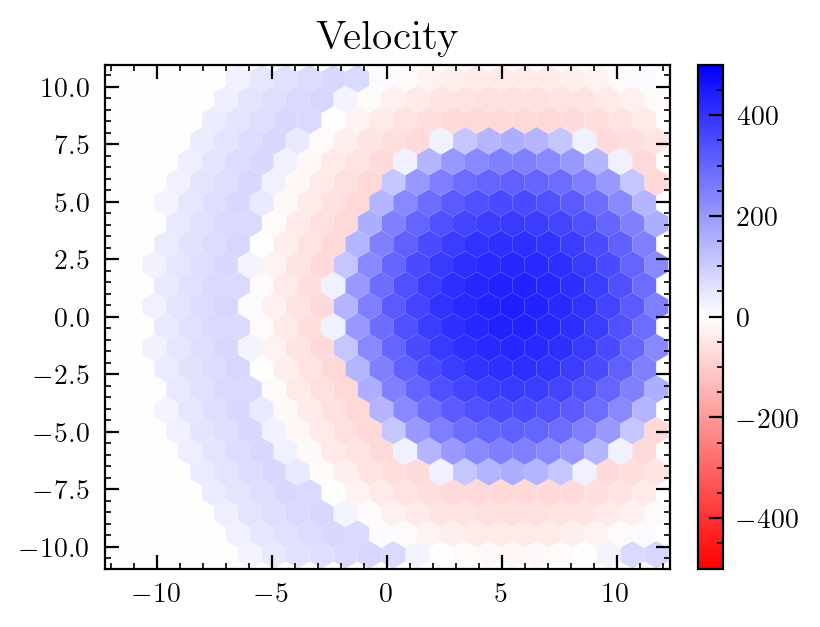

In [12]:
nearsum = np.sum(near, axis=0)

fig,ax = plt.subplots(1,1, layout='compressed'); fig.set_figwidth(4)
maps(nearsum, ax=ax, fig=fig, c=1, vlim=(-500,500))
ax.set_title(r'$\rm Velocity$');
